<a href="https://colab.research.google.com/github/agcaubagit/Colab/blob/main/CNN_GNN_Hybrid_Model_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
try:
    import torch_geometric
except Exception:

    !pip install -q torch_geometric

    import importlib
    importlib.invalidate_caches()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.9 MB/s eta 0:00:00


In [ ]:
!pip install -q rasterio geopandas scikit-learn matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.5/342.5 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.5/32.5 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 134.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 130.6 MB/s eta 0:00:00


In [ ]:
import os, math, warnings, json
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import rasterio
import geopandas as gpd
from shapely.geometry import Point
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt, seaborn as sns
from tqdm import tqdm
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import zoom

from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cpu


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
import os

IMAGE_PATH = '/content/drive/MyDrive/DATA_THESIS/Sat_Img/Thesis_SatelliteImage.tif'
BOUNDARY_SHP = '/content/drive/MyDrive/DATA_THESIS/Study_Area_bdry/StudyArea_PolBound.shp'
GT_CSV = '/content/drive/MyDrive/DATA_THESIS/Ground_Data/GroundTruthData_Complete_6.csv'
OUT_DIR = '/content/drive/MyDrive/DATA_THESIS/output'
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
LABEL_MAP = {'RICE':0, 'CORN':1, 'COCONUT':2, 'BANANA':3, 'WATER':4, 'BARREN':5, 'BUILT-UPS':6, 'FOREST':7}
INV_LABEL_MAP = {v:k for k,v in LABEL_MAP.items()}
NUM_TARGET_CLASSES = len(LABEL_MAP)

PATCH = 64
STRIDE = 48
BATCH = 32
EPOCHS = 120
LR = 1e-6
K = 5

In [ ]:
def compute_indices(blue, green, red, nir, swir1=None, rededge=None, eps=1e-6):

    # NDVI
    ndvi = (nir - red) / (nir + red + eps)

    # EVI
    evi = 2.5 * (nir - red) / (nir + 6*red - 7.5*blue + 1 + eps)

    # GNDVI
    gndvi = (nir - green) / (nir + green + eps)

    # SAVI
    savi = 1.5 * (nir - red) / (nir + red + 0.5 + eps)

    # NDWI (water index)
    ndwi = (nir - green) / (nir + green + eps)

    # NDMI (moisture index)
    if swir1 is not None:
        ndmi = (nir - swir1) / (nir + swir1 + eps)
    else:
        ndmi = np.zeros_like(nir)

    # NDRE (red edge vegetation index)
    if rededge is not None:
        ndre = (nir - rededge) / (nir + rededge + eps)
    else:
        ndre = np.zeros_like(nir)

    # Clip values to [-1,1]
    indices = {
        "NDVI": np.clip(ndvi, -1, 1),
        "EVI": np.clip(evi, -1, 1),
        "GNDVI": np.clip(gndvi, -1, 1),
        "SAVI": np.clip(savi, -1, 1),
        "NDWI": np.clip(ndwi, -1, 1),
        "NDMI": np.clip(ndmi, -1, 1),
        "NDRE": np.clip(ndre, -1, 1)
    }

    # Replace NaN and inf values
    for k in indices.keys():
        indices[k] = np.nan_to_num(indices[k], nan=0.0, posinf=0.0, neginf=0.0)

    return indices


def read_raster(path):
    src = rasterio.open(path)
    arr = src.read().astype(np.float32)
    profile = src.profile
    return arr, src, profile

def extract_patch(img, row, col, patch_size=PATCH):
    b, H, W = img.shape
    half = patch_size // 2
    r0 = max(0, row-half); c0 = max(0, col-half)
    r1 = min(H, row+half); c1 = min(W, col+half)
    patch = np.zeros((b, patch_size, patch_size), dtype=np.float32)
    pr = r1 - r0; pc = c1 - c0
    patch[:, :pr, :pc] = img[:, r0:r1, c0:c1]
    return patch


In [ ]:
import rasterio

print('Loading image...')
img, src, profile = read_raster(IMAGE_PATH)
print('Image shape (bands, H, W):', img.shape)
H, W = img.shape[1], img.shape[2]

Loading image...
Image shape (bands, H, W): (4, 17710, 14249)


In [ ]:
print('Normalize reflectance by 10000 and clip...')
img = img / 10000.0
img = np.clip(img, 0.0, 1.0)

Normalize reflectance by 10000 and clip...


In [ ]:
print('Computing NDVI...')
indices = compute_indices(
    blue = img[0],
    green = img[1],
    red = img[2],
    nir = img[3],
    swir1 = img[4] if img.shape[0] > 4 else None,
    rededge = img[5] if img.shape[0] > 5 else None
)

ndvi = indices["NDVI"]
evi = indices["EVI"]
gndvi = indices["GNDVI"]
savi = indices["SAVI"]
ndwi = indices["NDWI"]
full = np.concatenate([
    img,                          # 4 bands (B,G,R,NIR)
    ndvi[np.newaxis,...],
    evi[np.newaxis,...],
    gndvi[np.newaxis,...],
    savi[np.newaxis,...],
    ndwi[np.newaxis,...]
], axis=0)

Computing NDVI...


In [ ]:
print('Loading ground truth CSV...')
df = pd.read_csv(GT_CSV)
required = ['CROP TYPE','LATITUDE','LONGITUDE']
cols = [c.upper() for c in df.columns]
colmap = {c.upper():c for c in df.columns}
for rc in required:
    if rc not in cols:
        raise ValueError(f'CSV missing required column (case-insensitive): {rc}')
df = df.rename(columns={colmap['CROP TYPE']:'CROP TYPE', colmap['LATITUDE']:'LATITUDE', colmap['LONGITUDE']:'LONGITUDE'})
df['CROP TYPE'] = df['CROP TYPE'].astype(str).str.upper().str.strip()
df = df[df['CROP TYPE'].isin(LABEL_MAP.keys())].copy()
print('Ground truth points after filtering:', len(df))
if len(df)==0:
    raise RuntimeError('No valid ground truth points found.')

gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['LONGITUDE'], df['LATITUDE']), crs='EPSG:4326')
if gdf.crs != src.crs:
    gdf = gdf.to_crs(src.crs)

Loading ground truth CSV...
Ground truth points after filtering: 2983


In [ ]:
import geopandas as gpd
from sklearn.model_selection import train_test_split

bnds = gpd.read_file(BOUNDARY_SHP)
if bnds.crs != src.crs:
    bnds = bnds.to_crs(src.crs)

if 'Pro_Name' not in bnds.columns and 'PRO_NAME' in bnds.columns:
    bnds['Pro_Name'] = bnds['PRO_NAME']
bnds['Pro_Name'] = bnds['Pro_Name'].astype(str).str.upper()

train_poly = bnds[bnds['Pro_Name']=='AGUSAN DEL SUR']
test_poly  = bnds[bnds['Pro_Name']=='AGUSAN DEL NORTE']

if len(train_poly)==0:
    print('Warning: no train polygons found for AGUSAN DEL SUR; using all points as train.')
    gt_train = gdf.copy()
    gt_test = gpd.GeoDataFrame(columns=gdf.columns)
else:
    gt_train = gpd.sjoin(gdf, train_poly, how='inner', predicate='within')
    gt_test  = gpd.sjoin(gdf, test_poly, how='inner', predicate='within')

if len(gt_train) > 0:
    gt_train_split, gt_val_split = train_test_split(gt_train, test_size=0.2, random_state=SEED, stratify=gt_train['CROP TYPE'])
else:
    gt_train_split = gpd.GeoDataFrame(columns=gdf.columns)
    gt_val_split = gpd.GeoDataFrame(columns=gdf.columns)

print(f'Train points (AGUSAN DEL SUR): {len(gt_train_split)}')
print(f'Validation points (AGUSAN DEL SUR): {len(gt_val_split)}')
print(f'Transfer points (AGUSAN DEL NORTE): {len(gt_test)}')

if len(gt_train_split)==0:
    raise RuntimeError('No training points found in AGUSAN DEL SUR - check coordinates/CRS.')

Train points (AGUSAN DEL SUR): 2037
Validation points (AGUSAN DEL SUR): 510
Transfer points (AGUSAN DEL NORTE): 330


In [ ]:
def build_samples(gdf_points):
    samples = []
    for _, r in gdf_points.iterrows():
        x,y = r.geometry.x, r.geometry.y
        try:
            row, col = src.index(x,y)
        except Exception:
            continue
        if not (0 <= row < H and 0 <= col < W):
            continue
        patch = extract_patch(full, row, col, PATCH)  # use full 9-channel patch
        spec = np.array([
            full[0,row,col], full[1,row,col], full[2,row,col], full[3,row,col], # B,G,R,NIR
            full[4,row,col], full[5,row,col], full[6,row,col], full[7,row,col], full[8,row,col] # NDVI,EVI,GNDVI,SAVI,NDWI
        ], dtype=np.float32)

        label = LABEL_MAP.get(r['CROP TYPE'], None)
        if label is None: continue
        samples.append({'patch':patch, 'spec':spec, 'coords':(x,y), 'label':int(label)})
    return samples

train_samples = build_samples(gt_train_split)
val_samples = build_samples(gt_val_split)
transfer_samples = build_samples(gt_test)

print('Collected train samples:', len(train_samples), 'validation samples:', len(val_samples), 'transfer samples:', len(transfer_samples))
if len(train_samples)==0:
    raise RuntimeError('No train samples extracted - check overlap of CSV with raster.')

Collected train samples: 2037 validation samples: 510 transfer samples: 330


In [ ]:
#DataLoader
import random
from torch.utils.data import Dataset, DataLoader
import torch

class SimpleDataset(Dataset):
    def __init__(self, samples, augment=False):
        self.samples = samples
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        patch = s['patch'].astype(np.float32)
        spec = s['spec'].astype(np.float32)
        label = int(s['label'])

        #Augmentation
        if self.augment:
            patch_t = torch.from_numpy(patch)
            #Horizontal flip
            if random.random() > 0.5:
                patch_t = torch.flip(patch_t, dims=[2])
            #Vertical flip
            if random.random() > 0.5:
                patch_t = torch.flip(patch_t, dims=[1])
            #Random 90 degree rotation
            k = random.randint(0,3)
            patch_t = torch.rot90(patch_t, k, dims=[1,2])
            #slight brightness
            factor = 0.9 + 0.2*random.random()
            patch_t = torch.clamp(patch_t * factor, 0.0, 1.0)
            patch = patch_t.numpy()

        return torch.from_numpy(patch).float(), torch.from_numpy(spec).float(), torch.tensor(label).long(), torch.tensor(s['coords']).float()

#Training loader with augmentation
train_loader = DataLoader(SimpleDataset(train_samples, augment=True), batch_size=BATCH, shuffle=True, drop_last=False)
val_loader   = DataLoader(SimpleDataset(val_samples, augment=False), batch_size=BATCH, shuffle=False)
transfer_loader   = DataLoader(SimpleDataset(transfer_samples, augment=False), batch_size=BATCH, shuffle=False)

In [ ]:
from torchvision import models
class ResNet50Backbone(nn.Module):
    def __init__(self, out_dim=256, pretrained=True):
        super().__init__()
        res = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None)
        w = res.conv1.weight
        if w.shape[1] == 3:
          neww = torch.randn((w.shape[0], 9, w.shape[2], w.shape[3]))
          neww[:, :3, :, :] = w  # copy pretrained RGB weights
          neww[:, 3:, :, :] = w.mean(dim=1, keepdim=True)  # init other 6 channels
          res.conv1 = nn.Conv2d(9, res.conv1.out_channels,
                                kernel_size=res.conv1.kernel_size,
                                stride=res.conv1.stride,
                                padding=res.conv1.padding,
                                bias=res.conv1.bias)
          res.conv1.weight = nn.Parameter(neww)
        self.res = nn.Sequential(*list(res.children())[:-1])
        self.fc = nn.Sequential(nn.Linear(res.fc.in_features, out_dim), nn.ReLU())
    def forward(self, x):
        out = self.res(x)
        out = out.view(out.size(0), -1)
        return self.fc(out)


In [ ]:
class GraphSAGEModel(nn.Module):
    def __init__(self, in_dim, hid_dim=128, out_dim=128, num_layers=2):
        super().__init__()
        self.convs = nn.ModuleList()
        if num_layers == 1:
            self.convs.append(SAGEConv(in_dim, out_dim))
        else:
            self.convs.append(SAGEConv(in_dim, hid_dim))
            for _ in range(num_layers-2):
                self.convs.append(SAGEConv(hid_dim, hid_dim))
            self.convs.append(SAGEConv(hid_dim, out_dim))
        self.act = nn.ReLU()
    def forward(self, x, edge_index):
        for conv in self.convs:
            x = conv(x, edge_index)
            x = self.act(x)
        return x


In [ ]:
class Classifier(nn.Module):
    def __init__(self, feat_dim=256, gnn_dim=128, spec_dim=9, hidden=256, n_classes=NUM_TARGET_CLASSES):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(feat_dim + gnn_dim + spec_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, n_classes)
        )
    def forward(self, feat, gnn_feat, spec):
        x = torch.cat([feat, gnn_feat, spec], dim=1)
        return self.fc(x)

#Instantiate Models
backbone = ResNet50Backbone(out_dim=256, pretrained=True).to(DEVICE)
gnn = GraphSAGEModel(in_dim=256, hid_dim=128, out_dim=128, num_layers=2).to(DEVICE)
classifier = Classifier(feat_dim=256, gnn_dim=128, spec_dim=9, hidden=256).to(DEVICE)

optimizer = torch.optim.Adam(list(backbone.parameters()) + list(gnn.parameters()) + list(classifier.parameters()), lr=LR, weight_decay=1e-6)
criterion = nn.CrossEntropyLoss()


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 413MB/s]


In [ ]:
def compute_backbone_feats(samples_list, batch_size=64):
    backbone.eval()
    feats = []
    with torch.no_grad():
        for i in range(0, len(samples_list), batch_size):
            batch = samples_list[i:i+batch_size]
            patches = np.stack([s['patch'] for s in batch], axis=0)  # (B, C, H, W)
            p = torch.from_numpy(patches).float().to(DEVICE)
            patches = torch.nan_to_num(patches, nan=0.0, posinf=0.0, neginf=0.0)

            f = backbone(p)
            feats.append(f.cpu().numpy())
    feats = np.vstack(feats) if len(feats) else np.zeros((0,256), dtype=np.float32)
    return feats

In [ ]:
import random

random.seed(SEED)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, min_lr=1e-6)
early_stop_patience = 10
no_improve_epochs = 0

#Class Weights
# Use NUM_TARGET_CLASSES as the number of actual classes the model learns to predict
class_counts = np.array([np.sum([s['label']==i for s in train_samples]) for i in range(NUM_TARGET_CLASSES)])
print("Class counts (including new UNCLASSIFIED class from CSV):", class_counts)

weights = np.zeros_like(class_counts, dtype=np.float32)
nonzero_counts = class_counts
# Handle potential division by zero for classes with 0 samples
inv_freq = np.where(nonzero_counts > 0, 1.0 / nonzero_counts, 0.0)

weights = inv_freq
# Normalize weights to sum to NUM_TARGET_CLASSES
weights = weights / np.sum(weights) * NUM_TARGET_CLASSES

weights = torch.tensor(weights).float().to(DEVICE)
print("Shape of weights tensor before passing to CrossEntropyLoss:", weights.shape)
criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)

print("Class weights (for all target classes):")
for i, w in enumerate(weights.cpu().numpy()):
    print(f"  {INV_LABEL_MAP[i]}: {w:.6f}")

RESUME_TRAINING = True # Changed to True
CHECKPOINT_PATH = os.path.join(OUT_DIR, 'hybrid_model_v10.pth') # Changed to v6.pth

# Initialize lists to store metrics
epoch_losses = []
epoch_val_accs = []

if RESUME_TRAINING and os.path.exists(CHECKPOINT_PATH):
    print(f"Resuming training from {CHECKPOINT_PATH}")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    backbone.load_state_dict(checkpoint['backbone'])
    gnn.load_state_dict(checkpoint['gnn'])
    classifier.load_state_dict(checkpoint['classifier'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    scheduler.load_state_dict(checkpoint['scheduler'])
    best_val = checkpoint['best_val']
    if 'epoch_losses' in checkpoint:
        epoch_losses = checkpoint['epoch_losses']
    if 'epoch_val_accs' in checkpoint:
        epoch_val_accs = checkpoint['epoch_val_accs']
else:
    print("Starting training from scratch or current model state.")


def compute_backbone_feats(samples_list, batch_size=64):
    backbone.eval()
    feats = []
    with torch.no_grad():
        for i in range(0, len(samples_list), batch_size):
            batch = samples_list[i:i+batch_size]
            patches = np.stack([s['patch'] for s in batch], axis=0)  # (B, C, H, W)
            p = torch.from_numpy(patches).float().to(DEVICE)
            p = torch.nan_to_num(p, nan=0.0, posinf=0.0, neginf=0.0)
            f = backbone(p)
            feats.append(f.cpu().numpy())
    feats = np.vstack(feats) if len(feats) else np.zeros((0,256), dtype=np.float32)
    return feats


#Training
train_coords = np.array([s['coords'] for s in train_samples])
best_val = 0.0 if not epoch_val_accs else max(epoch_val_accs)
nan_log = os.path.join(OUT_DIR, 'nan_batches_log.txt')
open(nan_log,'w').close()

for epoch in range(len(epoch_losses), EPOCHS):
    backbone.train(); gnn.train(); classifier.train()
    epoch_loss = 0.0; batches=0

    train_feats = compute_backbone_feats(train_samples, batch_size=64)
    if train_feats.shape[0] == 0:
        raise RuntimeError('No train feats computed.')

    nbrs = NearestNeighbors(n_neighbors=K+1).fit(train_coords)
    dists, idxs = nbrs.kneighbors(train_coords)
    rows, cols = [], []
    Ntrain = len(train_coords)
    for i in range(Ntrain):
        neighs = idxs[i,1:]
        for j in neighs:
            rows.append(i); cols.append(j)
            rows.append(j); cols.append(i)
    edge_index = torch.tensor([rows, cols], dtype=torch.long).to(DEVICE)

    x_nodes = torch.from_numpy(train_feats).float().to(DEVICE)
    gnn_out = gnn(x_nodes, edge_index).detach().cpu().numpy()
    coord_to_idx = {tuple(train_samples[i]['coords']): i for i in range(len(train_samples))}

    for bidx, (patches, specs, labels, coords) in enumerate(train_loader):
        patches, specs, labels = patches.to(DEVICE), specs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        patches = torch.nan_to_num(patches, nan=0.0, posinf=1.0, neginf=0.0)
        specs = torch.nan_to_num(specs, nan=0.0, posinf=1.0, neginf=0.0)

        feats = backbone(patches)
        batch_gnn = []
        for c in coords.cpu().numpy():
            key = (float(c[0]), float(c[1]))
            idx = coord_to_idx.get(key, None)
            if idx is None:
                idx = np.argmin(np.linalg.norm(train_coords - c, axis=1))
            batch_gnn.append(gnn_out[idx])
        batch_gnn = torch.from_numpy(np.vstack(batch_gnn)).float().to(DEVICE)

        feats = torch.nan_to_num(feats, nan=0.0, posinf=1.0, neginf=0.0)
        batch_gnn = torch.nan_to_num(batch_gnn, nan=0.0, posinf=1.0, neginf=0.0)

        logits = classifier(feats, batch_gnn, specs)
        logits = torch.clamp(logits, -20, 20)
        loss = criterion(logits, labels)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f'[SKIP] NaN loss at epoch {epoch}, batch {bidx}')
            with open(nan_log,'a') as f:
                f.write(json.dumps({'epoch':int(epoch),'batch':int(bidx)}) + '\n')
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(backbone.parameters())+list(gnn.parameters())+list(classifier.parameters()), max_norm=1.0)
        optimizer.step()

        epoch_loss += float(loss.item()); batches += 1

    avg_loss = epoch_loss / max(1,batches)
    epoch_losses.append(avg_loss)

    #Validation
    backbone.eval(); gnn.eval(); classifier.eval()
    val_y_true = []; val_y_pred = []
    if len(val_samples) > 0:
        combined_train_val_samples = train_samples + val_samples
        combined_train_val_feats = compute_backbone_feats(combined_train_val_samples, batch_size=64)
        combined_train_val_coords = np.array([s['coords'] for s in combined_train_val_samples])

        nbrs_comb_val = NearestNeighbors(n_neighbors=K+1).fit(combined_train_val_coords)
        _, idxs_comb_val = nbrs_comb_val.kneighbors(combined_train_val_coords)
        rows_val, cols_val = [], []
        Ncomb_val = combined_train_val_coords.shape[0]
        for i in range(Ncomb_val):
            neighs = idxs_comb_val[i,1:]
            for j in neighs:
                rows_val.append(i); cols_val.append(j)
                rows_val.append(j); cols_val.append(i)
        edge_index_comb_val = torch.tensor([rows_val, cols_val], dtype=torch.long).to(DEVICE)
        x_comb_val = torch.from_numpy(combined_train_val_feats).float().to(DEVICE)
        with torch.no_grad():
            gnn_comb_val_out = gnn(x_comb_val, edge_index_comb_val).cpu().numpy()

        gnn_val_out = gnn_comb_val_out[len(train_samples):]
        val_backbone_feats = combined_train_val_feats[len(train_samples):]

        for i, s in enumerate(val_samples):
            feat = torch.from_numpy(val_backbone_feats[i]).unsqueeze(0).to(DEVICE)
            gfeat = torch.from_numpy(gnn_val_out[i]).unsqueeze(0).float().to(DEVICE)
            spec = torch.from_numpy(s['spec']).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                logits = classifier(feat, gfeat, spec)
                prob = F.softmax(logits, dim=1).cpu().numpy().squeeze(0)
                pred = int(np.argmax(prob))
                val_y_pred.append(pred); val_y_true.append(s['label'])
        val_acc = accuracy_score(val_y_true, val_y_pred) if len(val_y_true)>0 else 0.0
    else:
        val_acc = 0.0
    epoch_val_accs.append(val_acc)

    print(f'Epoch {epoch+1}/{EPOCHS} - loss {avg_loss:.4f} - val_acc {val_acc:.4f}')

    scheduler.step(val_acc)

    if val_acc > best_val:
        best_val = val_acc
        no_improve_epochs = 0
        torch.save({'backbone':backbone.state_dict(),
                    'gnn':gnn.state_dict(),
                    'classifier':classifier.state_dict(),
                    'optimizer':optimizer.state_dict(),
                    'scheduler':scheduler.state_dict(),
                    'best_val':best_val,
                    'epoch_losses': epoch_losses,
                    'epoch_val_accs': epoch_val_accs},
                    os.path.join(OUT_DIR,'hybrid_model_v10.pth'))
    else:
        no_improve_epochs += 1
        if no_improve_epochs >= early_stop_patience:
            print(f'Early stopping triggered after {epoch+1} epochs with no improvement.')
            break

print('Training finished. Best validation accuracy:', best_val)

Class counts (including new UNCLASSIFIED class from CSV): [662 313 555 182 147  41  93  44]
Shape of weights tensor before passing to CrossEntropyLoss: torch.Size([8])
Class weights (for all target classes):
  RICE: 0.157609
  CORN: 0.333345
  COCONUT: 0.187994
  BANANA: 0.573280
  WATER: 0.709775
  BARREN: 2.544802
  BUILT-UPS: 1.121902
  FOREST: 2.371293
Resuming training from /content/drive/MyDrive/DATA_THESIS/output/hybrid_model_v10.pth
Epoch 118/120 - loss 1.0409 - val_acc 0.9020
Epoch 119/120 - loss 1.0426 - val_acc 0.9039
Epoch 120/120 - loss 1.0305 - val_acc 0.9039
Training finished. Best validation accuracy: 0.907843137254902


Plot saved to /content/drive/MyDrive/DATA_THESIS/output/training_metrics.png


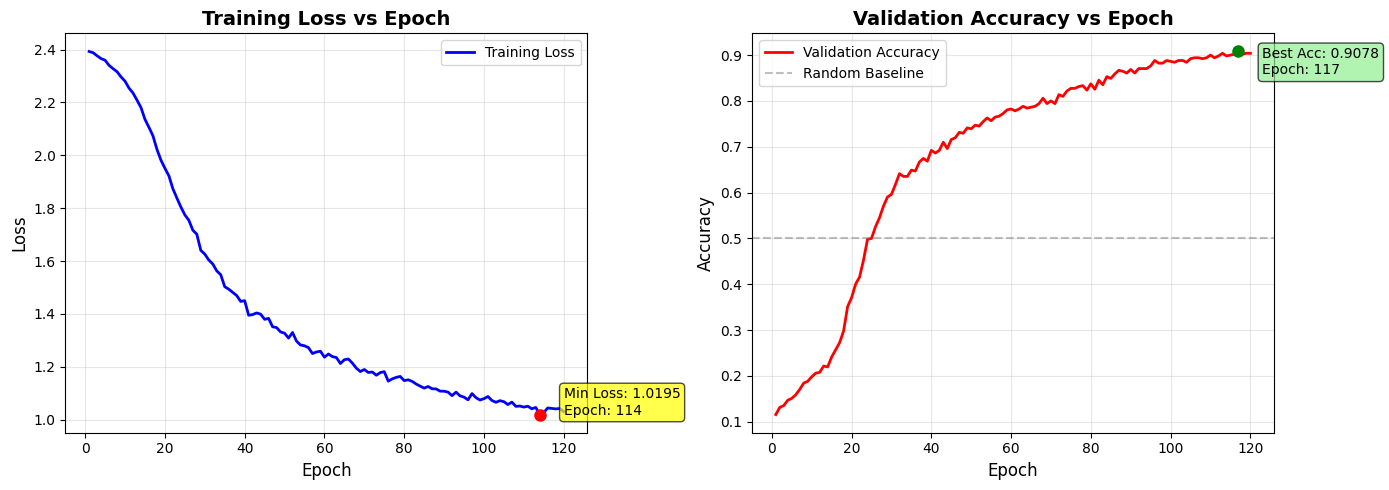


=== Training Summary ===
Total epochs: 120
Best validation accuracy: 0.9078 (Epoch 117)
Best training loss: 1.0195 (Epoch 114)
Final validation accuracy: 0.9039
Final training loss: 1.0305
Plot saved to /content/drive/MyDrive/DATA_THESIS/output/training_metrics_combined.png


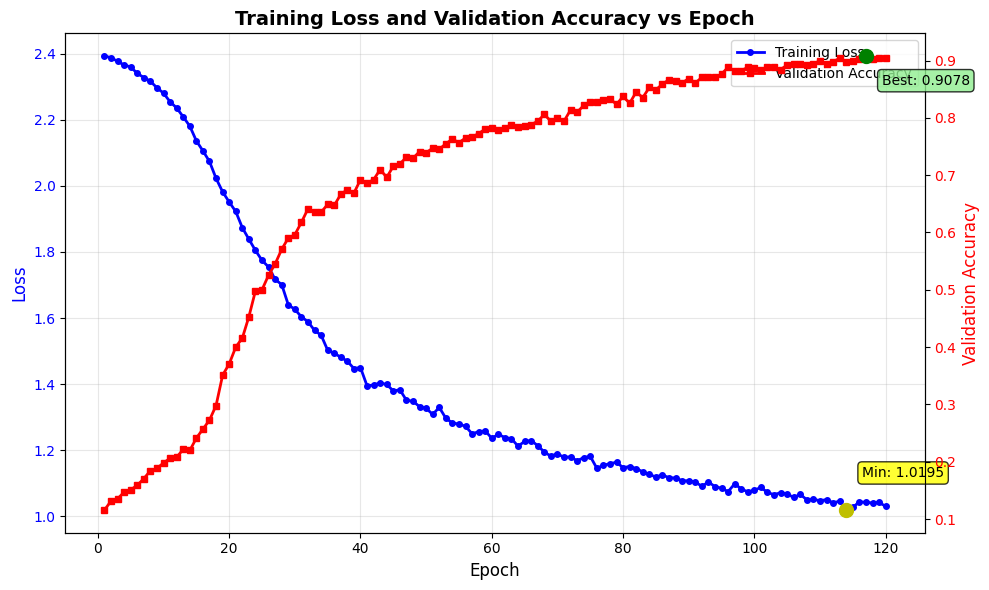

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import json

def plot_training_metrics(epoch_losses, epoch_val_accs, save_path=None):
    """
    Plot training loss and validation accuracy over epochs.

    Args:
        epoch_losses: List of training losses per epoch
        epoch_val_accs: List of validation accuracies per epoch
        save_path: Optional path to save the figure
    """
    epochs = range(1, len(epoch_losses) + 1)

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot training loss
    ax1.plot(epochs, epoch_losses, 'b-', linewidth=2, label='Training Loss')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Training Loss vs Epoch', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Add min loss annotation
    min_loss_epoch = np.argmin(epoch_losses) + 1
    min_loss = np.min(epoch_losses)
    ax1.plot(min_loss_epoch, min_loss, 'ro', markersize=8)
    ax1.annotate(f'Min Loss: {min_loss:.4f}\nEpoch: {min_loss_epoch}',
                 xy=(min_loss_epoch, min_loss),
                 xytext=(min_loss_epoch + len(epochs)*0.05, min_loss),
                 fontsize=10,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

    # Plot validation accuracy
    ax2.plot(epochs, epoch_val_accs, 'r-', linewidth=2, label='Validation Accuracy')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_title('Validation Accuracy vs Epoch', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    # Add max accuracy annotation
    max_acc_epoch = np.argmax(epoch_val_accs) + 1
    max_acc = np.max(epoch_val_accs)
    ax2.plot(max_acc_epoch, max_acc, 'go', markersize=8)
    ax2.annotate(f'Best Acc: {max_acc:.4f}\nEpoch: {max_acc_epoch}',
                 xy=(max_acc_epoch, max_acc),
                 xytext=(max_acc_epoch + len(epochs)*0.05, max_acc - 0.05),
                 fontsize=10,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))

    # Add horizontal line at 0.5 for reference
    ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random Baseline')
    ax2.legend()

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")

    plt.show()

    # Print summary statistics
    print("\n=== Training Summary ===")
    print(f"Total epochs: {len(epoch_losses)}")
    print(f"Best validation accuracy: {max_acc:.4f} (Epoch {max_acc_epoch})")
    print(f"Best training loss: {min_loss:.4f} (Epoch {min_loss_epoch})")
    print(f"Final validation accuracy: {epoch_val_accs[-1]:.4f}")
    print(f"Final training loss: {epoch_losses[-1]:.4f}")

def plot_training_metrics_combined(epoch_losses, epoch_val_accs, save_path=None):
    """
    Plot training loss and validation accuracy on the same figure with dual y-axes.

    Args:
        epoch_losses: List of training losses per epoch
        epoch_val_accs: List of validation accuracies per epoch
        save_path: Optional path to save the figure
    """
    epochs = range(1, len(epoch_losses) + 1)

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot training loss on primary y-axis
    color1 = 'blue'
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', color=color1, fontsize=12)
    ax1.plot(epochs, epoch_losses, color=color1, linewidth=2, marker='o', markersize=4, label='Training Loss')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(True, alpha=0.3)

    # Plot validation accuracy on secondary y-axis
    ax2 = ax1.twinx()
    color2 = 'red'
    ax2.set_ylabel('Validation Accuracy', color=color2, fontsize=12)
    ax2.plot(epochs, epoch_val_accs, color=color2, linewidth=2, marker='s', markersize=4, label='Validation Accuracy')
    ax2.tick_params(axis='y', labelcolor=color2)

    # Add title
    plt.title('Training Loss and Validation Accuracy vs Epoch', fontsize=14, fontweight='bold')

    # Add best accuracy annotation
    max_acc_epoch = np.argmax(epoch_val_accs) + 1
    max_acc = np.max(epoch_val_accs)
    ax2.plot(max_acc_epoch, max_acc, 'go', markersize=10, zorder=5)
    ax2.annotate(f'Best: {max_acc:.4f}',
                 xy=(max_acc_epoch, max_acc),
                 xytext=(max_acc_epoch + len(epochs)*0.02, max_acc - 0.05),
                 fontsize=10,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.8))

    # Add min loss annotation
    min_loss_epoch = np.argmin(epoch_losses) + 1
    min_loss = np.min(epoch_losses)
    ax1.plot(min_loss_epoch, min_loss, 'yo', markersize=10, zorder=5)
    ax1.annotate(f'Min: {min_loss:.4f}',
                 xy=(min_loss_epoch, min_loss),
                 xytext=(min_loss_epoch + len(epochs)*0.02, min_loss + 0.1),
                 fontsize=10,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.8))

    # Add legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")

    plt.show()

def plot_multiple_experiments(experiments, save_path=None):
    """
    Plot multiple experiments for comparison.

    Args:
        experiments: Dictionary with experiment names as keys and tuples of (losses, accuracies) as values
        save_path: Optional path to save the figure
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    colors = plt.cm.tab10(np.linspace(0, 1, len(experiments)))

    for idx, (exp_name, (losses, accuracies)) in enumerate(experiments.items()):
        epochs = range(1, len(losses) + 1)
        color = colors[idx]

        # Plot losses
        ax1.plot(epochs, losses, color=color, linewidth=2, marker='o', markersize=3, label=exp_name)
        ax1.set_xlabel('Epoch', fontsize=12)
        ax1.set_ylabel('Loss', fontsize=12)
        ax1.set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
        ax1.grid(True, alpha=0.3)

        # Plot accuracies
        ax2.plot(epochs, accuracies, color=color, linewidth=2, marker='s', markersize=3, label=exp_name)
        ax2.set_xlabel('Epoch', fontsize=12)
        ax2.set_ylabel('Validation Accuracy', fontsize=12)
        ax2.set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
        ax2.grid(True, alpha=0.3)

    ax1.legend()
    ax2.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")

    plt.show()

# Example usage with your training script:
if __name__ == "__main__":
    # Assuming epoch_losses and epoch_val_accs are defined in your training script

    # Method 1: Basic side-by-side plots
    plot_training_metrics(epoch_losses, epoch_val_accs,
                         save_path=os.path.join(OUT_DIR, 'training_metrics.png'))

    # Method 2: Combined plot with dual y-axes
    plot_training_metrics_combined(epoch_losses, epoch_val_accs,
                                  save_path=os.path.join(OUT_DIR, 'training_metrics_combined.png'))

    # If you want to plot multiple experiments (e.g., different runs)
    # experiments = {
    #     'Experiment 1': (epoch_losses_run1, epoch_val_accs_run1),
    #     'Experiment 2': (epoch_losses_run2, epoch_val_accs_run2),
    # }
    # plot_multiple_experiments(experiments, save_path=os.path.join(OUT_DIR, 'experiment_comparison.png'))

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
#Epochs Evaluation Graph

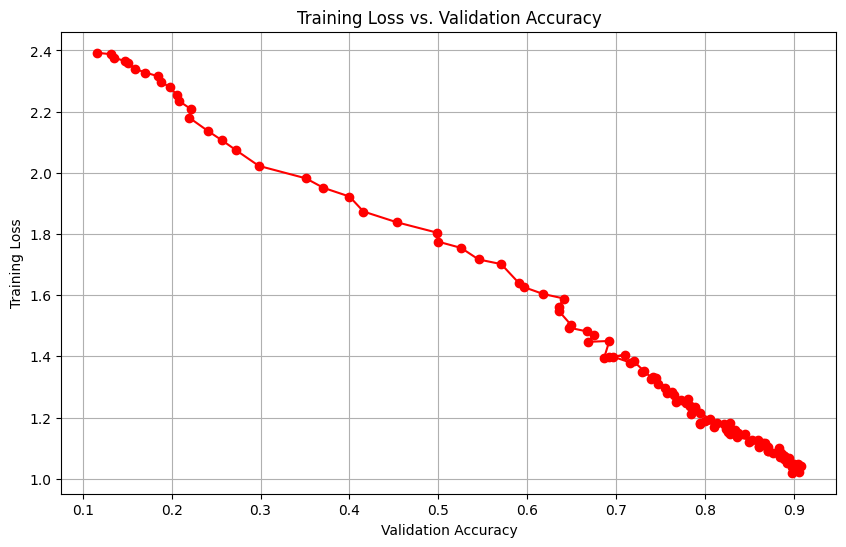

In [ ]:
import matplotlib.pyplot as plt

if not epoch_losses or not epoch_val_accs:
    print("Epoch losses or validation accuracies are not available. Please run the training cell first or ensure a checkpoint was loaded.")
else:
    plt.figure(figsize=(10, 6))
    plt.plot(epoch_val_accs, epoch_losses, marker='o', linestyle='-', color='r')
    plt.title('Training Loss vs. Validation Accuracy')
    plt.xlabel('Validation Accuracy')
    plt.ylabel('Training Loss')
    plt.grid(True)
    plt.show()

In [ ]:
#TRANSFERABILITY TESTING (AGUSAN DEL NORTE)

Training Accuracy: 0.9494354442808051
Classification Report:
               precision    recall  f1-score   support

           0     0.9788    0.9743    0.9765       662
           1     0.9231    0.9585    0.9404       313
           2     0.9625    0.9261    0.9440       555
           3     0.8850    0.9725    0.9267       182
           4     1.0000    0.8367    0.9111       147
           5     0.8723    1.0000    0.9318        41
           6     0.8654    0.9677    0.9137        93
           7     0.9778    1.0000    0.9888        44

    accuracy                         0.9494      2037
   macro avg     0.9331    0.9545    0.9416      2037
weighted avg     0.9516    0.9494    0.9494      2037



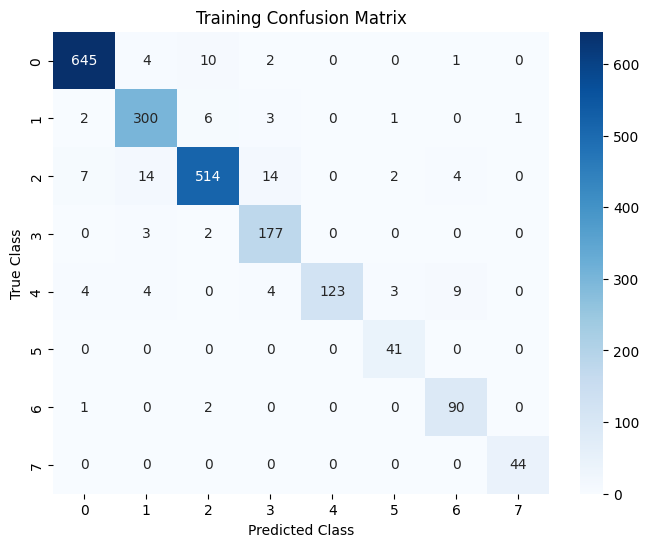

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

backbone.eval()
gnn.eval()
classifier.eval()

y_true = []
y_pred = []

train_coords = np.array([s['coords'] for s in train_samples])
train_feats = compute_backbone_feats(train_samples, batch_size=64)
nbrs = NearestNeighbors(n_neighbors=K+1).fit(train_coords)
_, idxs = nbrs.kneighbors(train_coords)
rows, cols = [], []
Ntrain = len(train_coords)
for i in range(Ntrain):
    neighs = idxs[i,1:]
    for j in neighs:
        rows.append(i); cols.append(j)
        rows.append(j); cols.append(i)
edge_index = torch.tensor([rows, cols], dtype=torch.long).to(DEVICE)
x_nodes = torch.from_numpy(train_feats).float().to(DEVICE)
with torch.no_grad():
    gnn_out = gnn(x_nodes, edge_index).cpu().numpy()

coord_to_idx = {tuple(train_samples[i]['coords']): i for i in range(len(train_samples))}

for s in train_samples:
    feat = torch.from_numpy(train_feats[coord_to_idx[tuple(s['coords'])]]).unsqueeze(0).to(DEVICE)
    gfeat = torch.from_numpy(gnn_out[coord_to_idx[tuple(s['coords'])]]).unsqueeze(0).to(DEVICE)
    spec = torch.from_numpy(s['spec']).unsqueeze(0).to(DEVICE)
    label = s['label']

    with torch.no_grad():
        logits = classifier(feat, gfeat, spec)
        pred = int(torch.argmax(logits, dim=1).cpu().numpy()[0])

    y_true.append(label)
    y_pred.append(pred)

train_acc = accuracy_score(y_true, y_pred)
print("Training Accuracy:", train_acc)
print("Classification Report:\n", classification_report(y_true, y_pred, digits=4))

#Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Training Confusion Matrix')
plt.show()


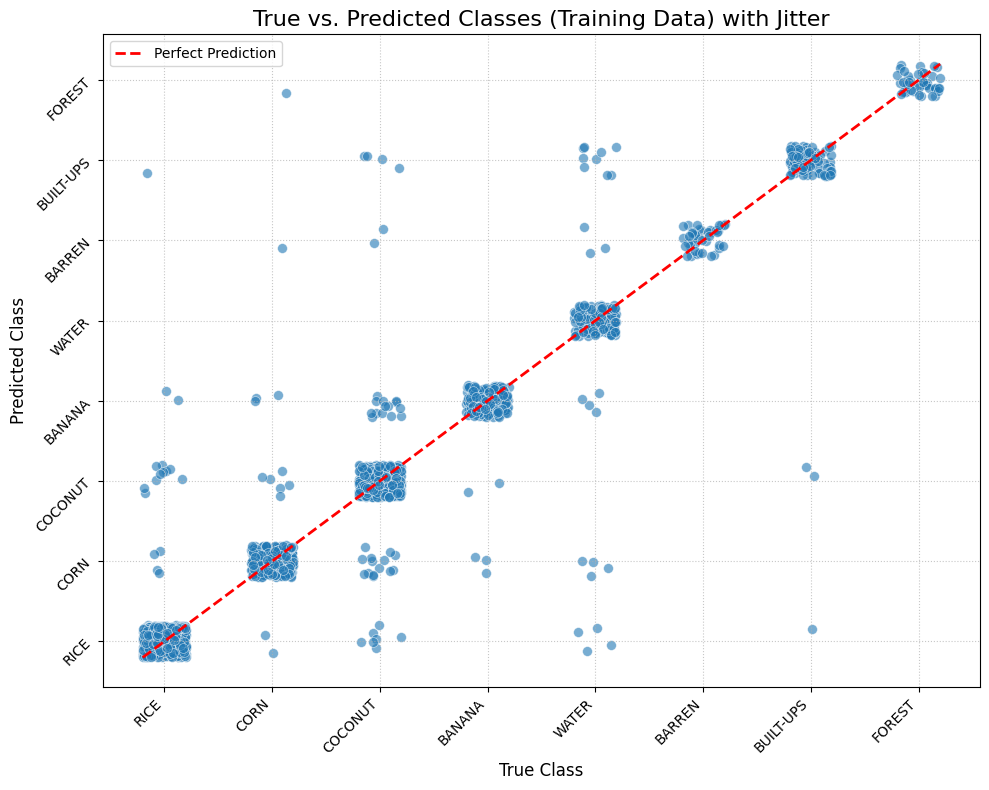

In [ ]:
import numpy as np

plt.figure(figsize=(10, 8)) # Slightly larger figure for better detail

# Add jitter to the points to avoid overplotting for discrete categories
jitter_strength = 0.2 # Adjust as needed
y_true_jittered = np.array(y_true) + np.random.uniform(-jitter_strength, jitter_strength, len(y_true))
y_pred_jittered = np.array(y_pred) + np.random.uniform(-jitter_strength, jitter_strength, len(y_pred))

# Plot the jittered points with increased size and transparency
plt.scatter(y_true_jittered, y_pred_jittered, alpha=0.6, s=50, edgecolors='w', linewidths=0.5)

# Add a perfect prediction line (diagonal line)
min_label = min(INV_LABEL_MAP.keys())
max_label = max(INV_LABEL_MAP.keys())
plt.plot([min_label - jitter_strength, max_label + jitter_strength],
         [min_label - jitter_strength, max_label + jitter_strength],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('True vs. Predicted Classes (Training Data) with Jitter', fontsize=16)
plt.xlabel('True Class', fontsize=12)
plt.ylabel('Predicted Class', fontsize=12)

# Set ticks and labels using the inverse label map
plt.xticks(list(INV_LABEL_MAP.keys()), list(INV_LABEL_MAP.values()), rotation=45, ha='right', fontsize=10)
plt.yticks(list(INV_LABEL_MAP.keys()), list(INV_LABEL_MAP.values()), rotation=45, ha='right', fontsize=10)

plt.grid(True, linestyle=':', alpha=0.7) # Finer grid lines
plt.legend() # Show the legend for the perfect prediction line
plt.tight_layout()
plt.show()

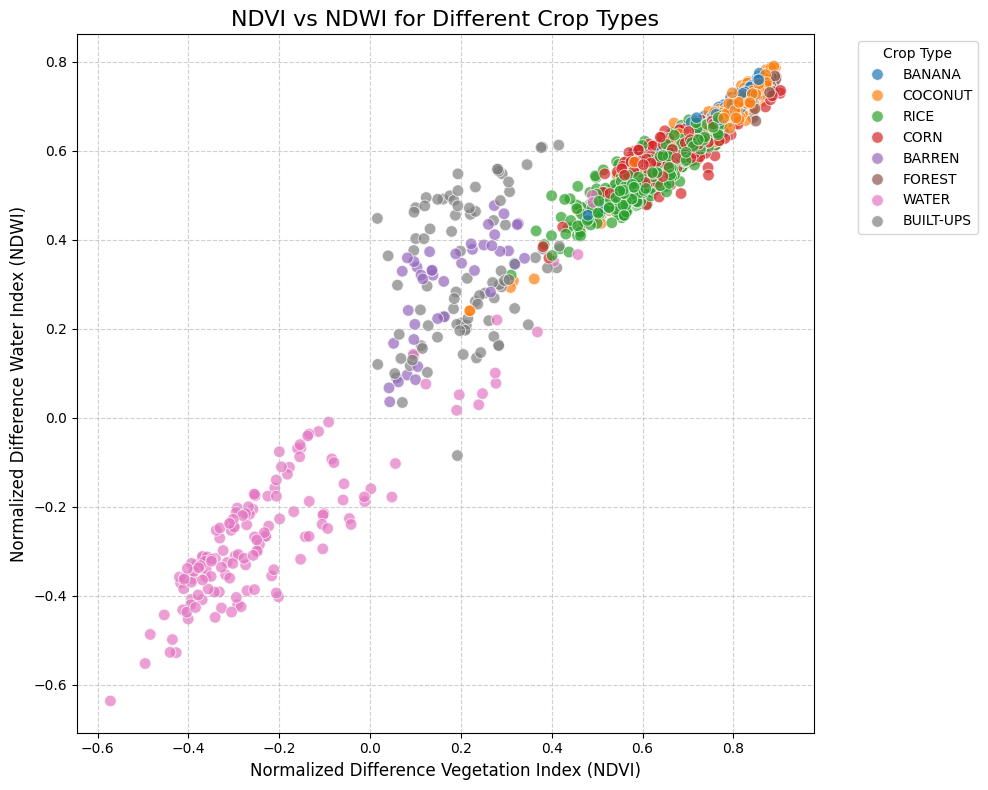

In [ ]:
# Prepare data for NDVI vs NDWI plot
plot_data_ndvi_ndwi = []
for i, sample in enumerate(train_samples):
    # Extract NDVI (index 4) and NDWI (index 8) values from the 'spec' array
    ndvi_val = sample['spec'][4]
    ndwi_val = sample['spec'][8]
    crop_type = INV_LABEL_MAP[sample['label']]
    plot_data_ndvi_ndwi.append({'NDVI': ndvi_val, 'NDWI': ndwi_val, 'Crop Type': crop_type})

df_ndvi_ndwi = pd.DataFrame(plot_data_ndvi_ndwi)

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_ndvi_ndwi, x='NDVI', y='NDWI', hue='Crop Type', palette='tab10', s=70, alpha=0.7)
plt.title('NDVI vs NDWI for Different Crop Types', fontsize=16)
plt.xlabel('Normalized Difference Vegetation Index (NDVI)', fontsize=12)
plt.ylabel('Normalized Difference Water Index (NDWI)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

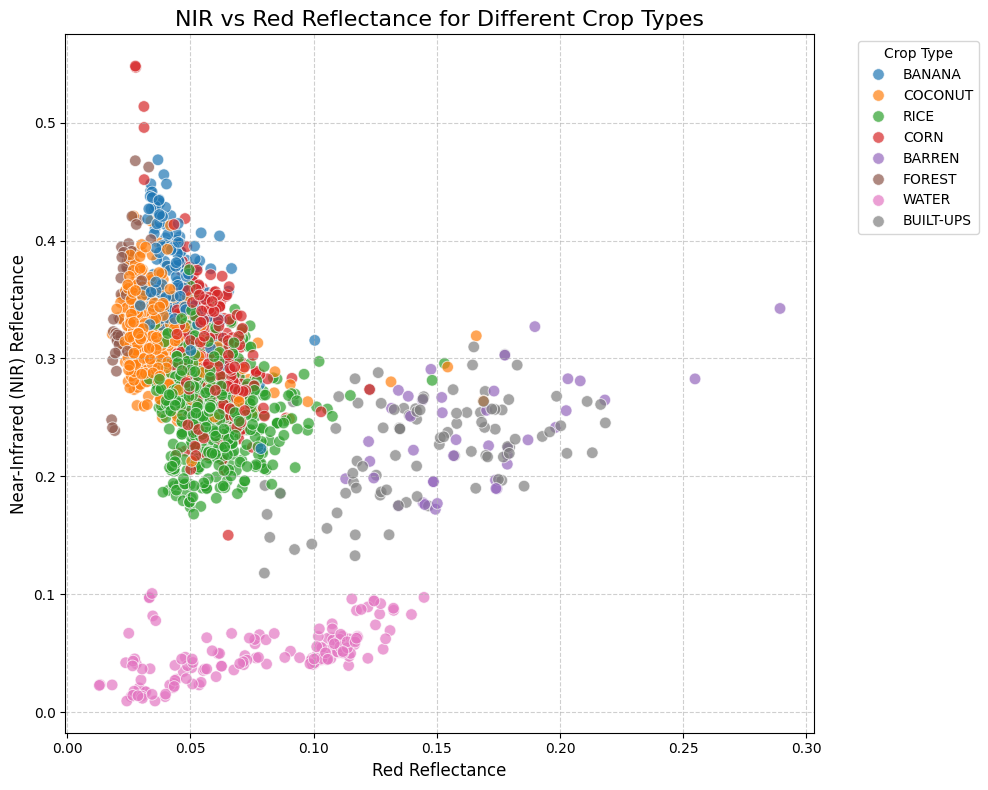

In [ ]:
# Prepare data for NIR vs Red plot
plot_data_nir_red = []
for i, sample in enumerate(train_samples):
    # Extract NIR (index 3) and Red (index 2) band values from the 'spec' array
    nir_val = sample['spec'][3]
    red_val = sample['spec'][2]
    crop_type = INV_LABEL_MAP[sample['label']]
    plot_data_nir_red.append({'NIR': nir_val, 'Red': red_val, 'Crop Type': crop_type})

df_nir_red = pd.DataFrame(plot_data_nir_red)

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_nir_red, x='Red', y='NIR', hue='Crop Type', palette='tab10', s=70, alpha=0.7)
plt.title('NIR vs Red Reflectance for Different Crop Types', fontsize=16)
plt.xlabel('Red Reflectance', fontsize=12)
plt.ylabel('Near-Infrared (NIR) Reflectance', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
sample_9layer_patches = {}

for sample in train_samples:
    label = sample['label']
    crop_type_name = INV_LABEL_MAP[label]
    patch = sample['patch'] # This patch already has all 9 layers

    # If we haven't collected a sample for this class yet
    if crop_type_name not in sample_9layer_patches:
        sample_9layer_patches[crop_type_name] = patch

print("Collected 9-layer sample patches for the following classes:")
for crop_type, patch_data in sample_9layer_patches.items():
    print(f"  - {crop_type}: {patch_data.shape}")

Collected 9-layer sample patches for the following classes:
  - BANANA: (9, 64, 64)
  - COCONUT: (9, 64, 64)
  - RICE: (9, 64, 64)
  - CORN: (9, 64, 64)
  - BARREN: (9, 64, 64)
  - FOREST: (9, 64, 64)
  - WATER: (9, 64, 64)
  - BUILT-UPS: (9, 64, 64)


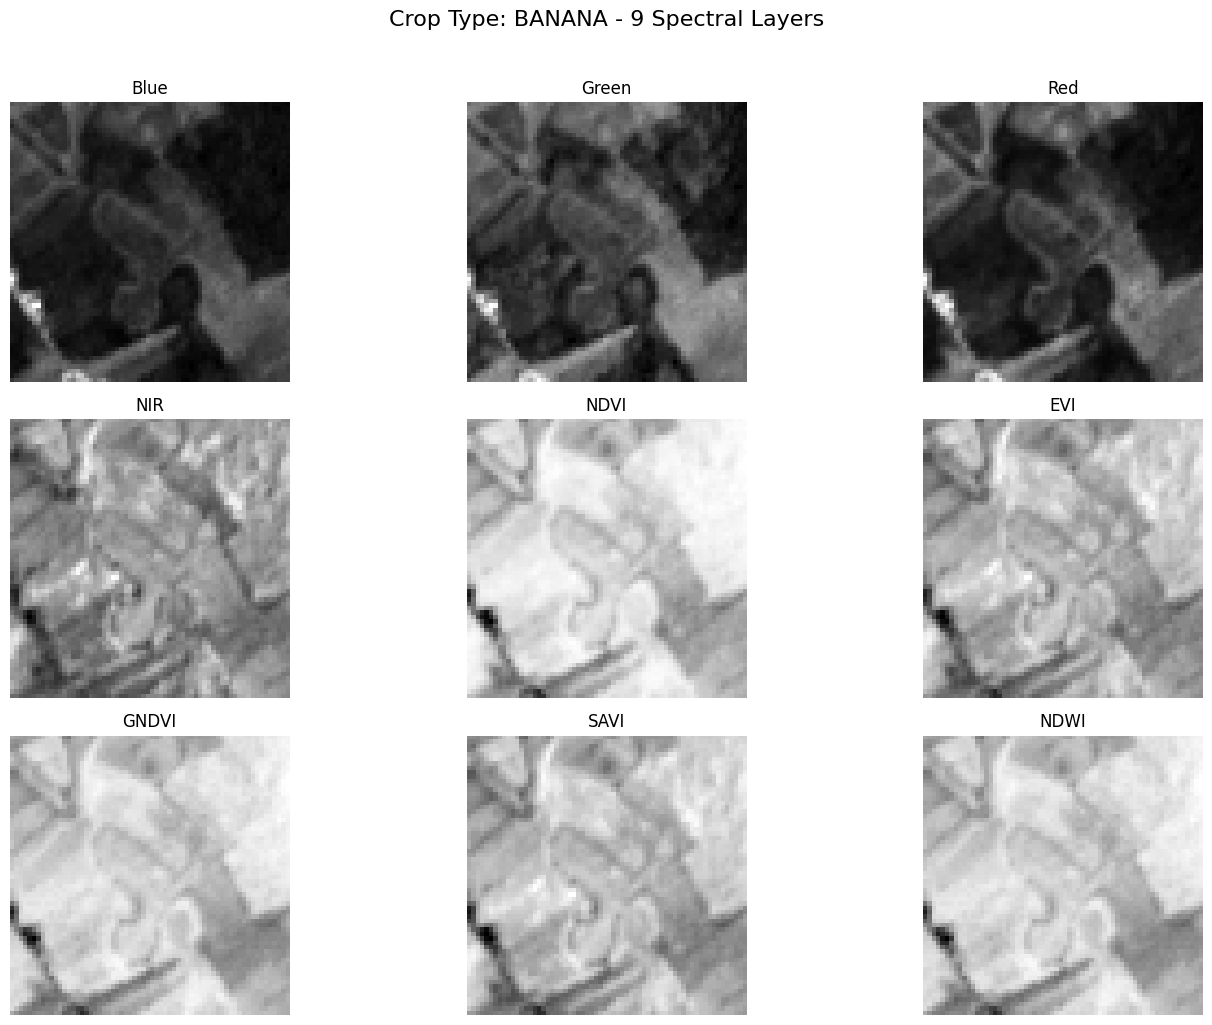

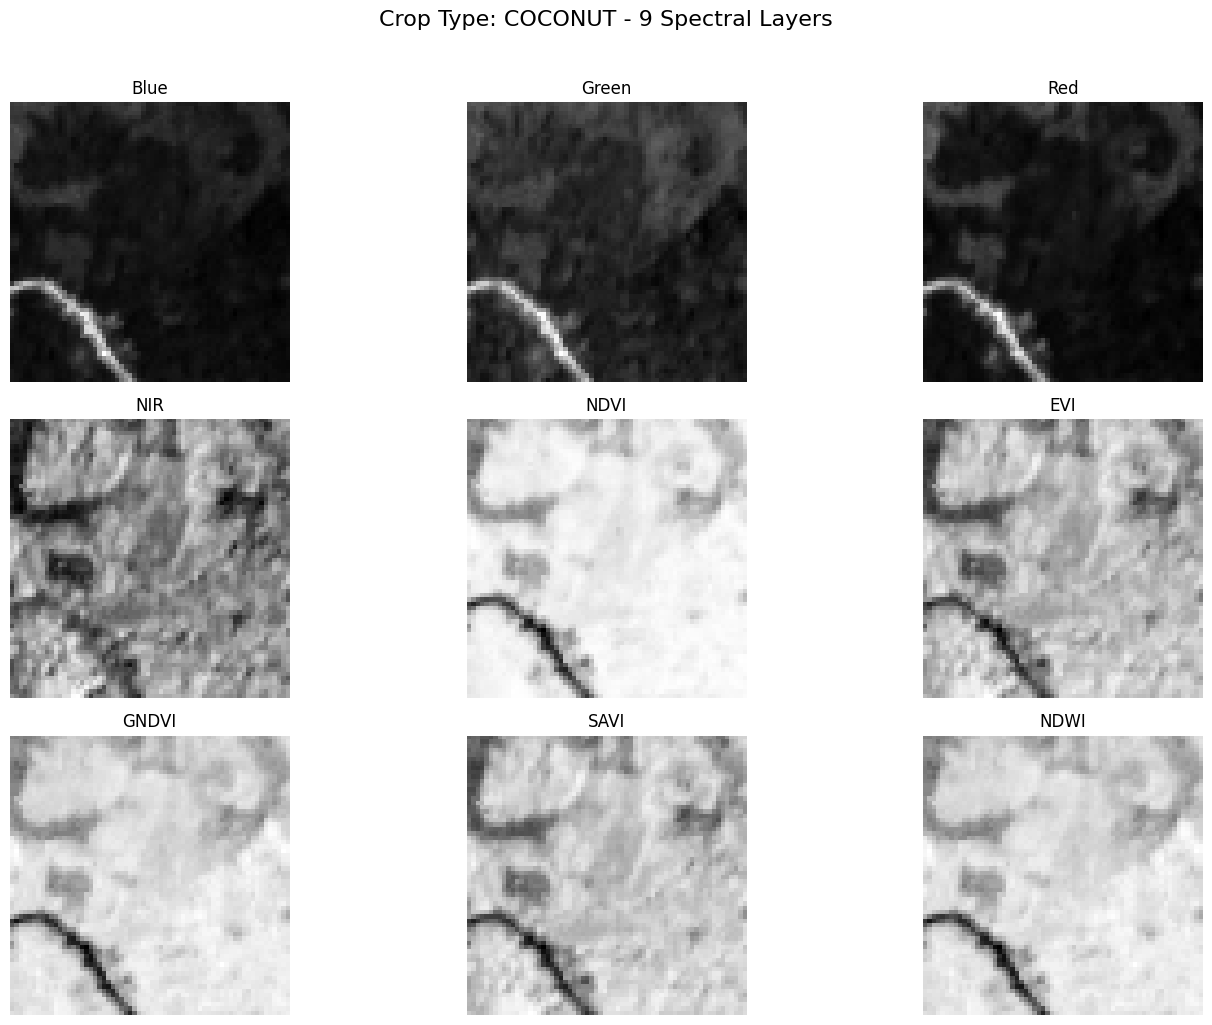

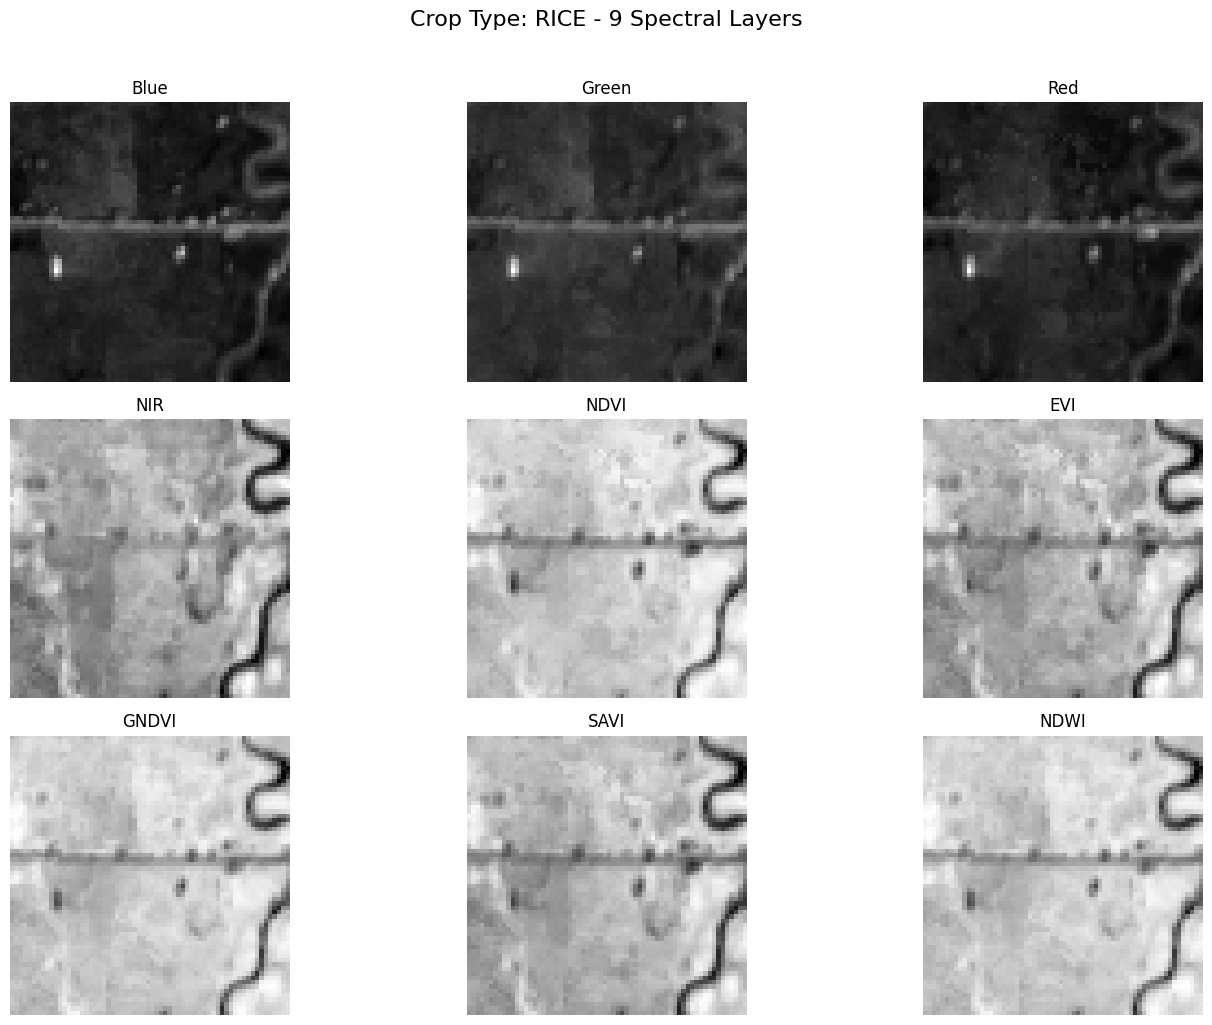

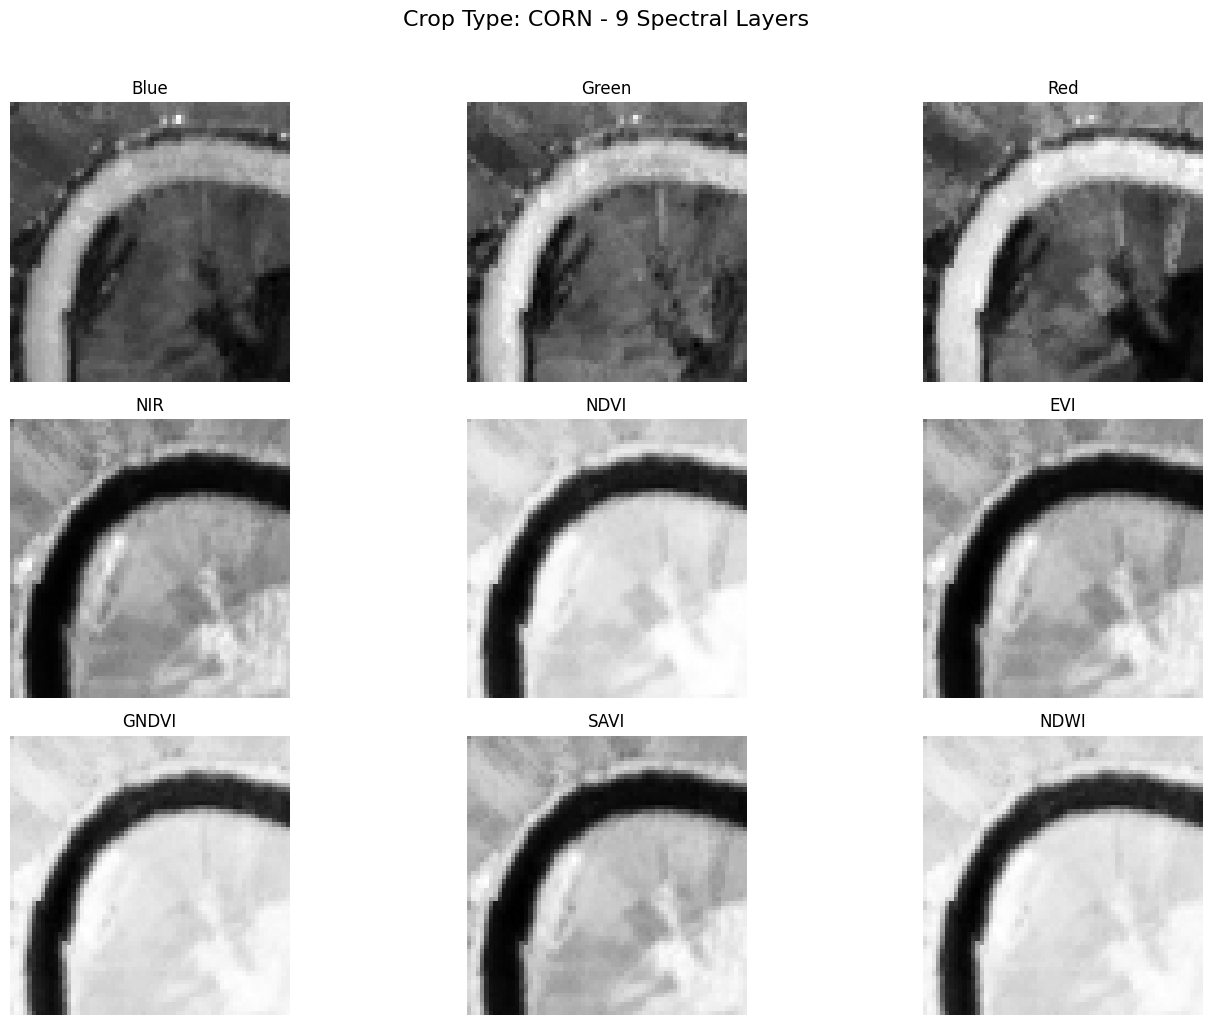

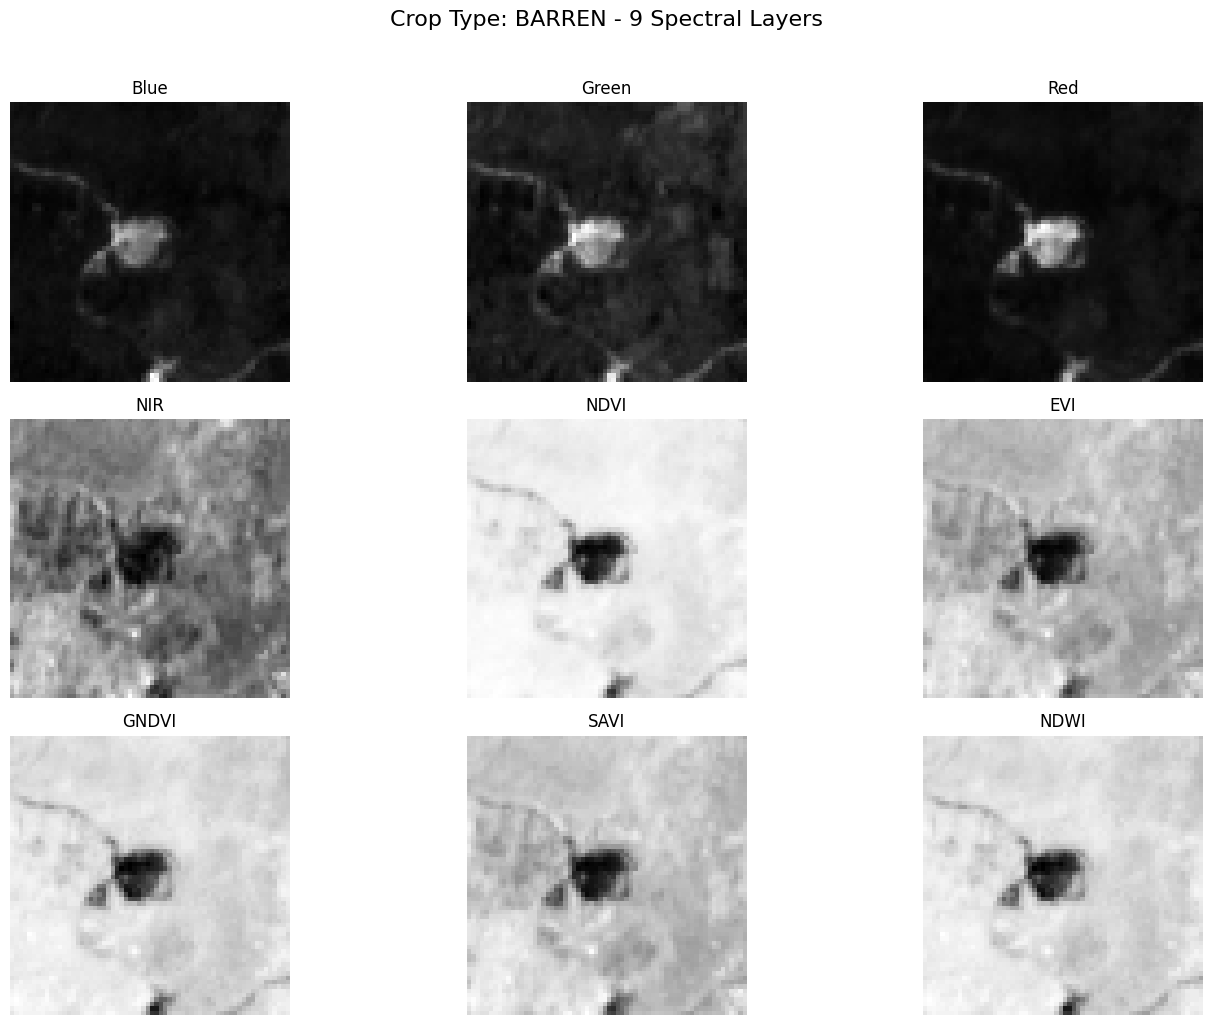

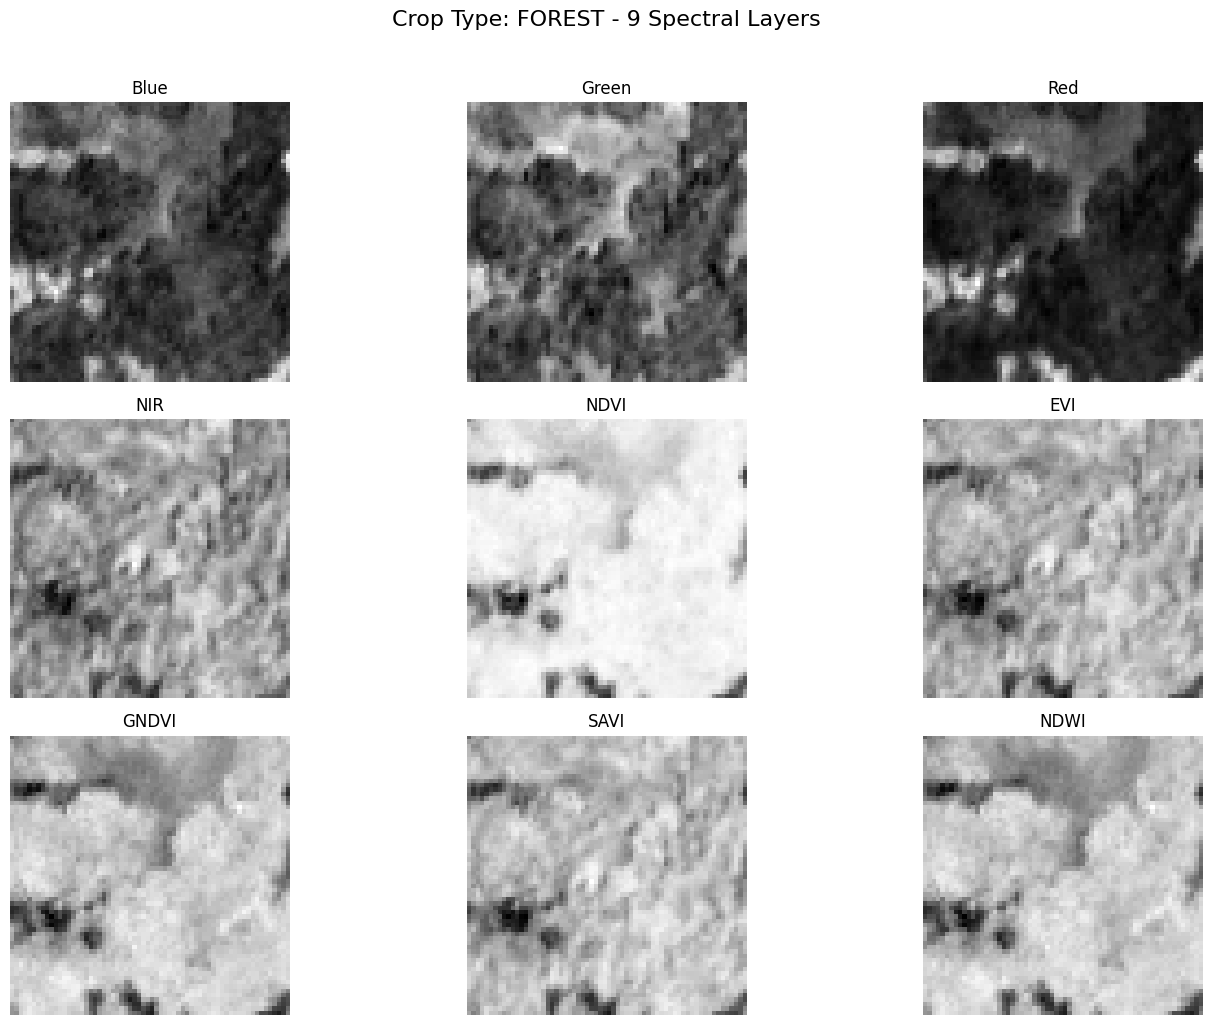

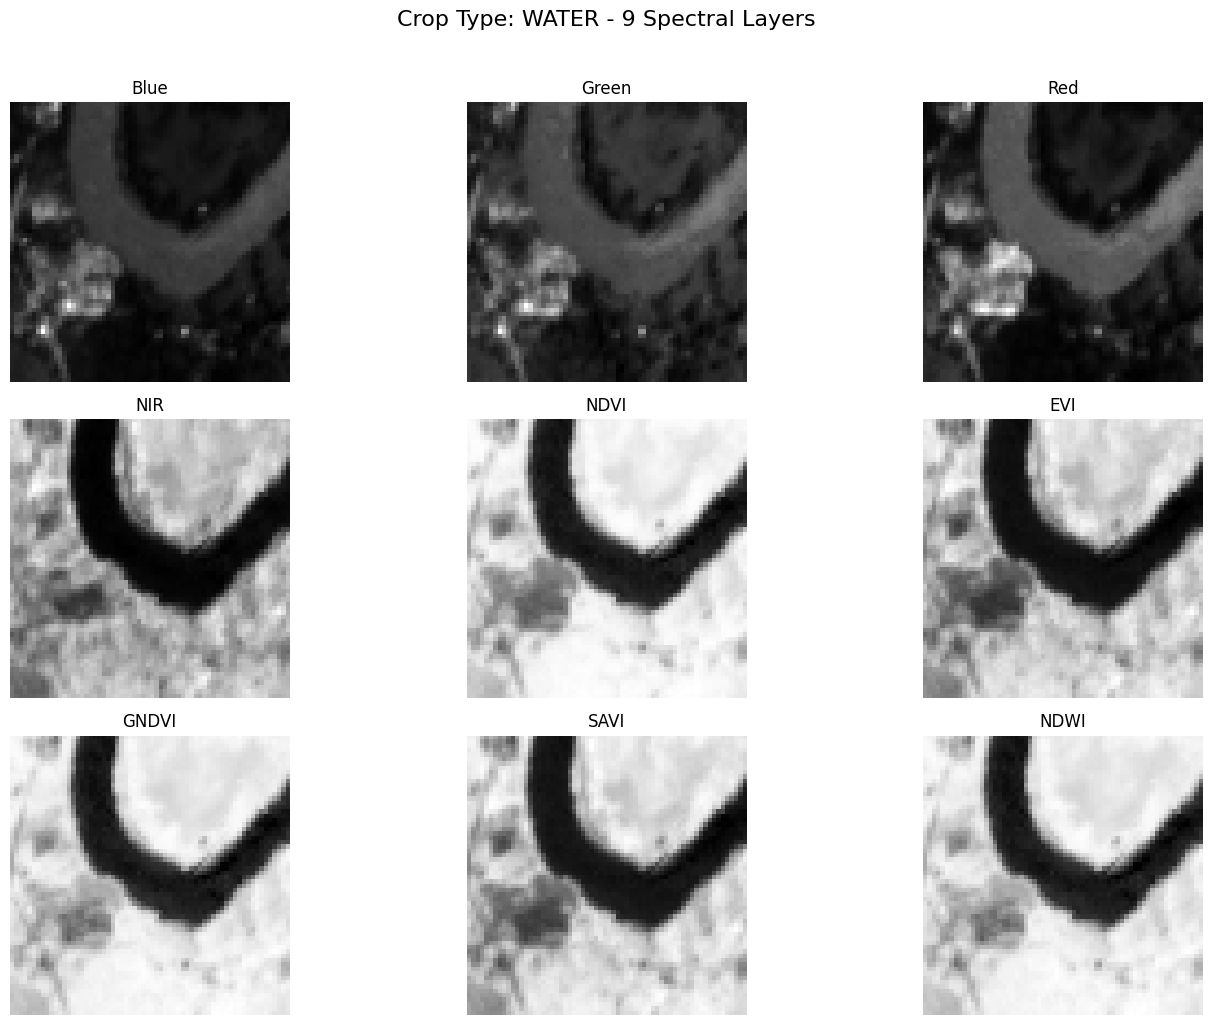

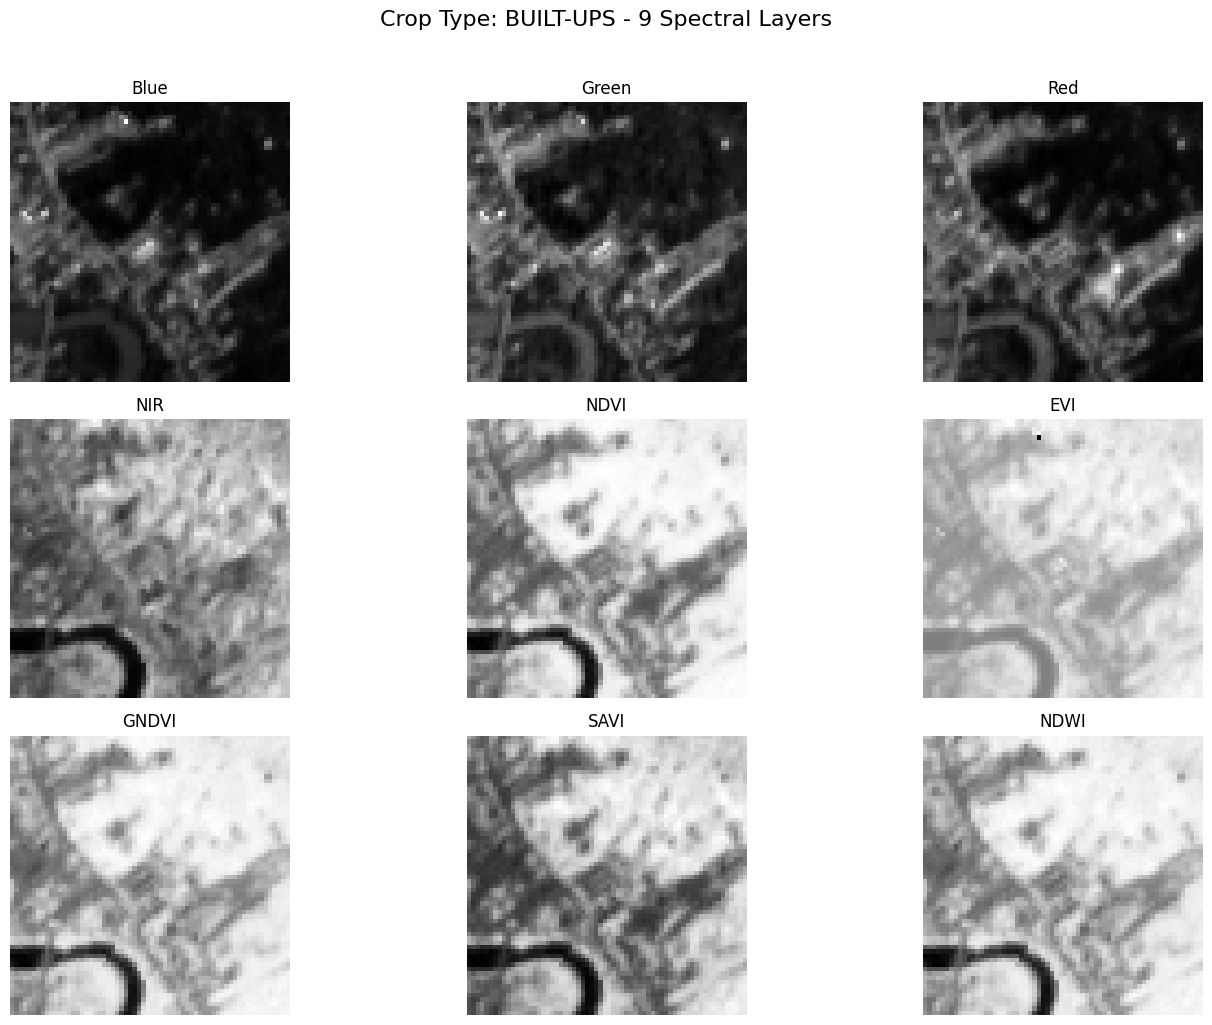

In [ ]:
feature_names = ['Blue', 'Green', 'Red', 'NIR', 'NDVI', 'EVI', 'GNDVI', 'SAVI', 'NDWI']

for crop_type_name, patch_data in sample_9layer_patches.items():
    plt.figure(figsize=(15, 10))
    plt.suptitle(f'Crop Type: {crop_type_name} - 9 Spectral Layers', fontsize=16, y=1.02)

    for i in range(patch_data.shape[0]): # Iterate through each layer
        plt.subplot(3, 3, i + 1) # 3 rows, 3 columns for 9 layers
        # Use 'gray' colormap for single-channel images
        plt.imshow(patch_data[i, :, :], cmap='gray')
        plt.title(feature_names[i], fontsize=12)
        plt.axis('off') # Hide axes for cleaner visualization

    plt.tight_layout()
    plt.show()